# Data Cleaning & Univariate Analysis
In this notebook, we will clean the dataset (specifically handling the `TotalCharges` column) and perform Univariate Analysis to understand the distribution of our individual features and the target variable (`Churn`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

# Load the dataset
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Dataset loaded successfully! Shape:", df.shape)

Dataset loaded successfully! Shape: (7043, 21)


## 1. Data Cleaning
If you noticed in the previous notebook, `TotalCharges` is listed as an `object` (string) instead of a float. This is because there are 11 empty space strings (`" "`) in that column. 
Let's convert those empty spaces to `NaN` (Not a Number) missing values, and then convert the column to numeric. Since 11 rows is a very small percentage of our 7,043 rows, we will simply drop them.

In [2]:
# Replace empty strings with NaN
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)

# Convert column to float
df['TotalCharges'] = df['TotalCharges'].astype(float)

# Drop the 11 rows with missing TotalCharges
df.dropna(inplace=True)

print("Missing values after cleaning:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nNew Shape:", df.shape)

Missing values after cleaning:
 Series([], dtype: int64)

New Shape: (7032, 21)


**Observations (Data Cleaning):**
> We just got rid of the empty strings in the TotalCharges column by converting them to NaN and then dropping the rows with NaN values. Since it is only 11 rows, it will not affect our analysis much.

## 2. Target Variable Analysis (`Churn`)
Before exploring other features, we must understand our target variable. Is our dataset balanced (equal number of churn vs non-churn) or imbalanced?

/var/folders/2q/59drq3tx29zgg92gy1d4870c0000gn/T/ipykernel_19545/1817131310.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Churn', palette='Set2')


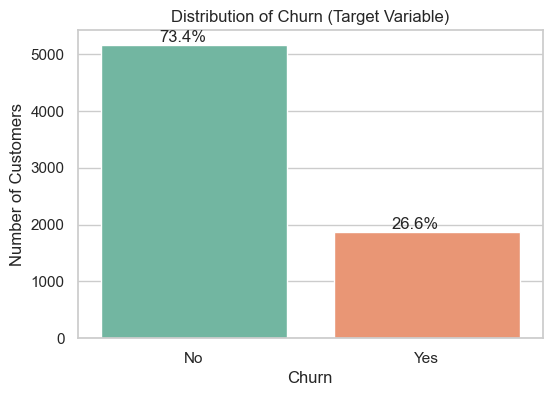

In [3]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Distribution of Churn (Target Variable)')
plt.ylabel('Number of Customers')

# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 50
    ax.annotate(percentage, (x, y), ha='center')

plt.show()

**Observations (Target Variable):**
> We see that the dataest is imbalanced, with only 26.5% of the customers churning. This might affect our machine learning models later. We will need to use techniques like SMOTE or class weights to handle this imbalance.

## 3. Univariate Analysis: Numerical Features
Let's look at the distributions of our numeric features: `tenure`, `MonthlyCharges`, and `TotalCharges`.

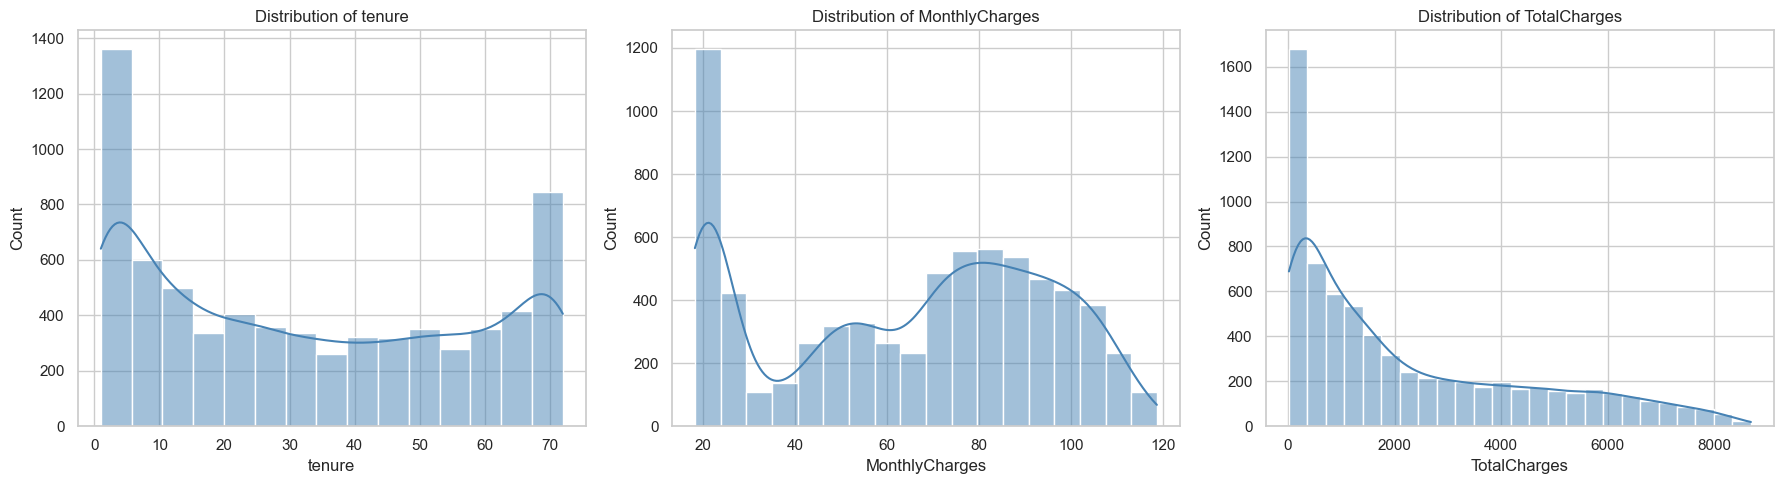

In [4]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

**Observations (Numerical Features):**
> Looking at tenure we can see that there are two peaks. SHowing lots of new clients and then a group of clients who have been with the company for a while. This is expected as new clients are more likely to churn. The monthly charges chart shows a two peak distribution showing that  there are a lot of clients on lower monthly charges and a smaller group of clients on higher monthly charges. This is expected as 

## 4. Univariate Analysis: Demographics
Let's explore demographic categorical features: `gender`, `SeniorCitizen`, `Partner`, and `Dependents`.

/var/folders/2q/59drq3tx29zgg92gy1d4870c0000gn/T/ipykernel_19545/3549656542.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[row, col_idx], palette='Pastel1')
/var/folders/2q/59drq3tx29zgg92gy1d4870c0000gn/T/ipykernel_19545/3549656542.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[row, col_idx], palette='Pastel1')
/var/folders/2q/59drq3tx29zgg92gy1d4870c0000gn/T/ipykernel_19545/3549656542.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[row, col_idx], pa

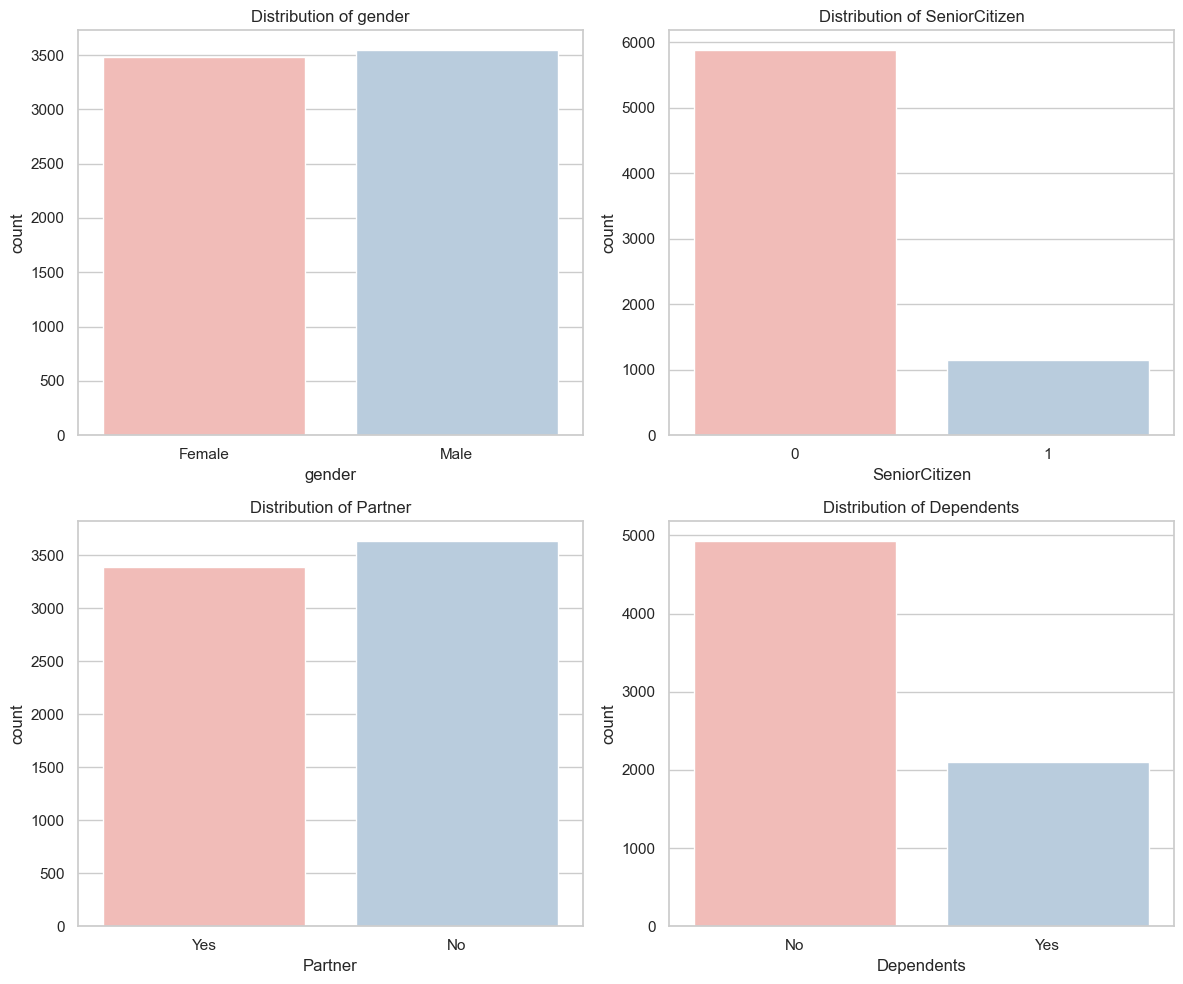

In [5]:
demo_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, col in enumerate(demo_features):
    row, col_idx = divmod(i, 2)
    sns.countplot(data=df, x=col, ax=axes[row, col_idx], palette='Pastel1')
    axes[row, col_idx].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

**Observations (Demographics):**
> *Write your observations here. For instance, are there more young customers or Senior Citizens?*